# 7 Kỹ Thuật Chunking

## Tổng quan các phương pháp

| # | Kỹ thuật | Nguyên lý |
|---|---|---|
| 1 | **Fixed-size** | Chia theo số ký tự cố định |
| 2 | **Recursive** | Chia theo separator ưu tiên |
| 3 | **Structure-based** | Chia theo heading Điều/Chương |
| 4 | **Semantic** | Chia tại điểm thay đổi ngữ nghĩa (underthesea) |
| 5 | **Sliding Window** | Cửa sổ trượt có overlap |
| 6 | **Hierarchical** | Cây 3 cấp: Chương → Điều → Khoản |
| 7 | **Agentic** | LLM (Google Gemini) tự phân tích và chia |


---
## Load dữ liệu

In [1]:
import re
import json
import numpy as np
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

In [2]:
FILE_PATH = "quy-che-dao-tao-theo-he-thong-tin-chi-php.md"

with open(FILE_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

# Bỏ YAML front-matter (--- ... ---)
text = re.sub(r'^---.*?---\n', '', raw_text, flags=re.DOTALL).strip()

In [3]:
print(f"Tổng ký tự  : {len(text):,}")
print(f"Tổng từ     : {len(text.split()):,}")
print(f"Tổng dòng   : {text.count(chr(10)):,}")
print(f"Tổng câu (ước tính): {len(re.split(r'[.!?;]', text)):,}")

# Thống kê cấu trúc
chuong = re.findall(r'^## CHƯƠNG.*', text, re.MULTILINE)
dieu   = re.findall(r'^# Điều \d+\.', text, re.MULTILINE)
print(f"\nSố Chương   : {len(chuong)}")
print(f"Số Điều     : {len(dieu)}")
print("\n── 300 ký tự đầu ──")
print(text[:300])

Tổng ký tự  : 39,814
Tổng từ     : 8,745
Tổng dòng   : 461
Tổng câu (ước tính): 426

Số Chương   : 5
Số Điều     : 22

── 300 ký tự đầu ──
## CHƯƠNG I

NHỮNG QUY ĐỊNH CHUNG
# Điều 4. Các hệ đào tạo và thời gian đào tạo
1. Các hệ đào tạo

Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các b


---
## Hàm tiện ích & Tiêu chí đánh giá

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Data classes
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Chunk:
    """Đơn vị chunk cơ bản."""
    id: int
    text: str
    metadata: Dict = field(default_factory=dict)


@dataclass
class HierarchicalChunk:
    """Chunk có cấu trúc phân cấp cha–con."""
    id: int
    text: str
    level: str                            # 'parent' | 'child'
    parent_id: Optional[int]
    children_ids: List[int] = field(default_factory=list)
    metadata: Dict = field(default_factory=dict)


# ─────────────────────────────────────────────────────────────────────────────
#  7 Tiêu chí đánh giá
# ─────────────────────────────────────────────────────────────────────────────

EVAL_CRITERIA = """
╔══════════════════════════════════════════════════════════════════════════════════╗
║          7 TIÊU CHÍ ĐÁNH GIÁ CHẤT LƯỢNG CHUNKING                              ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  C1. TÍNH NHẤT QUÁN KÍCH THƯỚC (Size Consistency)                              ║
║      Đo: CV% = σ/μ x 100                                                        ║
║      Tốt: CV < 30%  |  Chấp nhận: 30-60%  |  Kém: > 60%                       ║
║      Ảnh hưởng: quản lý context window LLM, tối ưu batch embedding             ║
║                                                                                  ║
║  C2. ĐỘ PHỦ TÀI LIỆU (Coverage %)                                              ║
║      Đo: Σ(len_chunk) / len(doc) x 100                                          ║
║      Mục tiêu: ≥ 95% | Có overlap → > 100% là bình thường                      ║
║      Cảnh báo < 90%: có thể bị mất thông tin quan trọng                         ║
║                                                                                  ║
║  C3. TOÀN VẸN NGỮ NGHĨA (Semantic Integrity)                                   ║
║      Đo: định tính — chunk hoàn chỉnh ý nghĩa, không cắt giữa Điều/Khoản       ║
║      Tốt nhất: Structure-based ★, Semantic, Agentic                             ║
║      Rủi ro cao: Fixed-size (cắt tại ký tự bất kỳ)                             ║
║                                                                                  ║
║  C4. HIỆU SUẤT XỬ LÝ (Throughput — ký tự/giây)                                ║
║      Fixed / Sliding / Hierarchical : O(n)        ⚡⚡⚡  > 10 MB/s             ║
║      Recursive / Structure-based    : O(n log n)  ⚡⚡   ~ 1-5 MB/s            ║
║      Semantic (TF-IDF)              : O(n x k²)   ⚡    ~ few seconds/MB       ║
║      Agentic (LLM API)              : O(n/token)  🐢   100-500 ms/chunk        ║
║                                                                                  ║
║  C5. KIỂM SOÁT OVERLAP & DƯ THỪA (Redundancy Control)                         ║
║      Overlap = (coverage% - 100%) thể hiện mức độ trùng lặp                    ║
║      Overlap tốt: 10-20% chunk_size (giữ ngữ cảnh qua ranh giới)               ║
║      Overlap quá cao: tăng cost lưu trữ, embedding, inference                   ║
║                                                                                  ║
║  C6. PHÙ HỢP LOẠI TÀI LIỆU (Domain Fitness)                                   ║
║      Pháp quy / học thuật cấu trúc rõ  → Structure-based  ★★★★★               ║
║      Văn bản thông thường / FAQ / chat → Recursive         ★★★★☆               ║
║      Cần multi-granularity retrieval   → Hierarchical      ★★★★☆               ║
║      Văn bản đa chủ đề phức tạp        → Semantic          ★★★★☆               ║
║      Tài liệu nhỏ cần chất lượng tối đa → Agentic          ★★★★★               ║
║                                                                                  ║
║  C7. CHI PHÍ & KHẢ NĂNG MỞ RỘNG (Cost & Scalability)                          ║
║      Fixed / Sliding / Hierarchical / Recursive : $0, scale dễ dàng            ║
║      Semantic (TF-IDF local)                    : $0 + CPU/GPU nhỏ             ║
║      Semantic (embedding model)                 : $GPU hoặc API cost           ║
║      Agentic (LLM)                              : $$$ API, không scale tốt     ║
║                                                                                  ║
╚══════════════════════════════════════════════════════════════════════════════════╝
"""
print(EVAL_CRITERIA)


╔══════════════════════════════════════════════════════════════════════════════════╗
║          7 TIÊU CHÍ ĐÁNH GIÁ CHẤT LƯỢNG CHUNKING                              ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║                                                                                  ║
║  C1. TÍNH NHẤT QUÁN KÍCH THƯỚC (Size Consistency)                              ║
║      Đo: CV% = σ/μ x 100                                                        ║
║      Tốt: CV < 30%  |  Chấp nhận: 30-60%  |  Kém: > 60%                       ║
║      Ảnh hưởng: quản lý context window LLM, tối ưu batch embedding             ║
║                                                                                  ║
║  C2. ĐỘ PHỦ TÀI LIỆU (Coverage %)                                              ║
║      Đo: Σ(len_chunk) / len(doc) x 100                                          ║
║      Mục tiêu: ≥ 95% | Có overlap → > 100% là bình thường                   

In [5]:
def evaluate_chunks(chunks: List[Chunk], method_name: str) -> Dict:
    """
    Tính 9 chỉ số định lượng đánh giá chất lượng chunking.

    Chỉ số              Ý nghĩa
    ─────────────────── ──────────────────────────────────────────────────────
    num_chunks          Tổng số chunk
    avg_chars           Số ký tự trung bình mỗi chunk
    std_chars           Độ lệch chuẩn kích thước
    min/max_chars       Kích thước nhỏ nhất / lớn nhất
    avg_words           Số từ trung bình mỗi chunk
    coverage_%          Tỉ lệ phủ tài liệu gốc (>100% nếu có overlap)
    size_cv_%           CV = σ/μ×100 (thấp → kích thước đều)
    tiny_chunks(<50)    Số chunk quá nhỏ (<50 ký tự)
    large_chunks(>2000) Số chunk quá lớn (>2000 ký tự)
    """
    if not chunks:
        return {"method": method_name, "num_chunks": 0}

    sizes = [len(c.text) for c in chunks]
    wc    = [len(c.text.split()) for c in chunks]

    return {
        "method"             : method_name,
        "num_chunks"         : len(chunks),
        "avg_chars"          : round(np.mean(sizes), 1),
        "std_chars"          : round(np.std(sizes), 1),
        "min_chars"          : min(sizes),
        "max_chars"          : max(sizes),
        "avg_words"          : round(np.mean(wc), 1),
        "coverage_%"         : round(sum(sizes) / len(text) * 100, 1),
        "size_cv_%"          : round(np.std(sizes) / np.mean(sizes) * 100, 1),
        "tiny_chunks(<50)"   : sum(1 for s in sizes if s < 50),
        "large_chunks(>2000)": sum(1 for s in sizes if s > 2000),
    }

In [6]:
from typing import List

def show_samples(chunks: List, n: int = 2, max_len: int = 1000, tail: bool = False):
    """Hiển thị n chunk mẫu. Nếu `tail=True` thì hiển thị n chunk cuối (end samples)."""
    pos = 'cuối' if tail else 'đầu'
    print(f"\n  ── {n} chunk mẫu minh họa ({pos}) ──")
    seq = chunks[-n:] if tail else chunks[:n]
    
    for c in seq:
        # preview = c.text[:max_len].replace('\n', ' ')
        preview = c.text[:max_len]
        if len(c.text) > max_len:
            preview += "..."
        meta_items = list(c.metadata.items())[:3]
        meta_str = ", ".join([f"{k}={v}" for k, v in meta_items])
        print(f"\n  [Chunk {c.id:02d}] ({len(c.text)} chars) | {meta_str}")
        print(f"{preview}")
        print("*"*50)

In [7]:
def print_metrics(m: Dict):
    """In bảng metrics ra console."""
    if "num_chunks" not in m:
        print(f"\n{m['method']}: {m.get('note', 'no data')}")
        return
    cv_flag = ' Đều' if m['size_cv_%'] < 50 else ' Không đều'
    cov_flag = ' Tốt' if m['coverage_%'] >= 95 else ' Thiếu'
    print(f"\n{'='*58}")
    print(f"  {m['method']}")
    print(f"{'='*58}")
    print(f"  Số lượng chunk             : {m['num_chunks']:>8}")
    print(f"  Ký tự TB / chunk           : {m['avg_chars']:>8.1f}")
    print(f"  Độ lệch chuẩn (chars)      : {m['std_chars']:>8.1f}")
    print(f"  Min / Max chars            : {m['min_chars']:>6} / {m['max_chars']}")
    print(f"  Từ TB / chunk              : {m['avg_words']:>8.1f}")
    print(f"  Độ phủ tài liệu            : {m['coverage_%']:>7.1f}%  {cov_flag}")
    print(f"  CV kích thước              : {m['size_cv_%']:>7.1f}%  {cv_flag}")
    print(f"  Chunk quá nhỏ (<50 chars)  : {m['tiny_chunks(<50)']:>8}")
    print(f"  Chunk quá lớn (>2000 chars): {m['large_chunks(>2000)']:>8}")

In [8]:
ALL_METRICS: List[Dict] = []
print("Hàm tiện ích đã sẵn sàng.")

Hàm tiện ích đã sẵn sàng.


---
## 1  Fixed-size Chunking

**Nguyên lý:** Chia văn bản thành các đoạn có độ dài **cố định** (ký tự), với `overlap` để tránh mất ngữ cảnh tại ranh giới.

```
  |── chunk_size=500 ──|
  |─ overlap=50 ─|── chunk_size=500 ──|
         |─ overlap=50 ─|── chunk_size=500 ──|
```

**Ưu điểm:** Cực đơn giản, O(n), kiểm soát chính xác kích thước context window.  
**Nhược điểm:** Có thể cắt giữa câu, đoạn văn, hoặc giữa quy định pháp lý.

**Đánh giá theo 7 tiêu chí:**
| Tiêu chí | Điểm | Ghi chú |
|---|:---:|---|
| C1. Nhất quán kích thước | ★★★★★ | CV rất thấp (gần 0%) |
| C2. Độ phủ | ★★★★☆ | Đủ, nhưng overlap tăng coverage |
| C3. Toàn vẹn ngữ nghĩa | ★☆☆☆☆ | Cắt tùy tiện, không tôn trọng câu/Điều |
| C4. Hiệu suất | ★★★★★ | O(n), cực nhanh |
| C5. Kiểm soát overlap | ★★★☆☆ | Overlap cố định, dễ tính |
| C6. Phù hợp domain | ★★☆☆☆ | Kém với văn bản pháp quy có cấu trúc |
| C7. Chi phí & scale | ★★★★★ | $0, không giới hạn |

**Tổng:** 24/35 — Chỉ phù hợp prototype hoặc indexing siêu nhanh.

In [9]:
def fixed_size_chunking(
    text: str,
    chunk_size: int = 500,
    overlap: int = 50,
) -> List[Chunk]:
    if overlap >= chunk_size:
        raise ValueError("overlap phải nhỏ hơn chunk_size")

    chunks: List[Chunk] = []
    step = chunk_size - overlap
    start = 0

    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk_text = text[start:end]
        if chunk_text.strip():
            chunks.append(Chunk(
                id=len(chunks),
                text=chunk_text,
                metadata={
                    "char_start": start,
                    "char_end"  : end,
                    "overlap"   : overlap,
                },
            ))
        start += step

    return chunks

In [10]:
fixed_chunks = fixed_size_chunking(text, chunk_size=500, overlap=50)

m1 = evaluate_chunks(fixed_chunks, "1. Fixed-size Chunking")
ALL_METRICS.append(m1)
print_metrics(m1)


  1. Fixed-size Chunking
  Số lượng chunk             :       89
  Ký tự TB / chunk           :    496.8
  Độ lệch chuẩn (chars)      :     30.1
  Min / Max chars            :    214 / 500
  Từ TB / chunk              :    109.7
  Độ phủ tài liệu            :   111.1%   Tốt
  CV kích thước              :     6.1%   Đều
  Chunk quá nhỏ (<50 chars)  :        0
  Chunk quá lớn (>2000 chars):        0


In [11]:
show_samples(fixed_chunks, n=2, max_len=500)


  ── 2 chunk mẫu minh họa (đầu) ──

  [Chunk 00] (500 chars) | char_start=0, char_end=500, overlap=50
## CHƯƠNG I

NHỮNG QUY ĐỊNH CHUNG
# Điều 4. Các hệ đào tạo và thời gian đào tạo
1. Các hệ đào tạo

Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:

– Đào tạo trình độ đại học chính quy: thực hiện 3,5 – 4,5 năm;

– Đào tạo trình độ đại học liên thông từ trung cấp: thực hiện 2,5 
**************************************************

  [Chunk 01] (500 chars) | char_start=450, char_end=950, overlap=50
độ đại học liên thông từ trung cấp: thực hiện 2,5 – 3,5 năm;

– Đào tạo trình độ đại học liên thông từ cao đẳng: thực hiện 1,5 – 2 năm;

– Đào tạo trình độ đại học vừa làm vừa học: thực hiện 4 – 5 năm;

– Đào tạo trình độ đại học liên thông đại học – đại học: thực hiện 2,5 – 

---
## 2️  Recursive Chunking

**Nguyên lý:** Chia theo danh sách **separator ưu tiên từ cao → thấp**.  
Nếu sau khi tách bằng `separator[0]` mà chunk con vẫn quá lớn → đệ quy với `separator[1]`, v.v.

```
  separators = ['\n\n', '\n', '. ', '! ', '; ', ' ']
                 ↑ ưu tiên cao nhất           ↑ thấp nhất
```

**Ưu điểm:** Giữ ranh giới tự nhiên (đoạn văn → câu → từ), linh hoạt.  
**Nhược điểm:** Kích thước không đồng đều; độ phức tạp cao hơn Fixed-size.

**Đánh giá theo 7 tiêu chí:**
| Tiêu chí | Điểm | Ghi chú |
|---|:---:|---|
| C1. Nhất quán kích thước | ★★★☆☆ | Biến động theo cấu trúc văn bản |
| C2. Độ phủ | ★★★★★ | Phủ toàn bộ, không mất nội dung |
| C3. Toàn vẹn ngữ nghĩa | ★★★★☆ | Ưu tiên ranh giới đoạn/câu tự nhiên |
| C4. Hiệu suất | ★★★★☆ | O(n log n), nhanh |
| C5. Kiểm soát overlap | ★★☆☆☆ | Không có overlap mặc định |
| C6. Phù hợp domain | ★★★★☆ | Tốt với mọi loại văn bản |
| C7. Chi phí & scale | ★★★★★ | $0, không giới hạn |

**Tổng:** 27/35 — **General-purpose tốt nhất** khi không biết trước cấu trúc.

In [12]:
def recursive_chunking(
    text: str,
    max_chunk_size: int = 500,
    separators: Optional[List[str]] = None,
) -> List[Chunk]:
    """
    Chia đệ quy theo danh sách separator ưu tiên.

    Thuật toán:
        1. Thử tách text bằng separators[0] (ưu tiên cao nhất).
        2. Gom các phần liên tiếp vào buffer cho đến khi vượt max_chunk_size.
        3. Khi buffer đầy → flush thành chunk.
        4. Nếu một phần đơn > max_chunk_size → đệ quy với separators[1:].
        5. Nếu hết separators → giữ nguyên (tránh vòng lặp vô hạn).

    Args:
        max_chunk_size : Số ký tự tối đa.
        separators     : Danh sách separator theo thứ tự ưu tiên giảm dần.
    """
    if separators is None:
        separators = ["\n\n", "\n", ". ", "! ", "? ", "; ", ", ", " "]

    def _split(t: str, seps: List[str]) -> List[str]:
        # Base case: đủ nhỏ hoặc hết separator
        if len(t) <= max_chunk_size or not seps:
            return [t]

        sep = seps[0]
        parts = t.split(sep)
        result: List[str] = []
        cur = ""

        for part in parts:
            candidate = cur + (sep if cur else "") + part
            if len(candidate) <= max_chunk_size:
                cur = candidate
            else:
                if cur:
                    result.append(cur)
                # Nếu part đơn vẫn quá lớn → đệ quy
                if len(part) > max_chunk_size:
                    result.extend(_split(part, seps[1:]))
                    cur = ""
                else:
                    cur = part

        if cur:
            result.append(cur)
        return result

    raw_chunks = _split(text, separators)
    return [
        Chunk(
            id=i,
            text=c.strip(),
            metadata={"method": "recursive", "len": len(c.strip())},
        )
        for i, c in enumerate(raw_chunks) if c.strip()
    ]

In [13]:
recursive_chunks = recursive_chunking(text, max_chunk_size=500)
m2 = evaluate_chunks(recursive_chunks, "2. Recursive Chunking")
ALL_METRICS.append(m2)
print_metrics(m2)


  2. Recursive Chunking
  Số lượng chunk             :      111
  Ký tự TB / chunk           :    356.7
  Độ lệch chuẩn (chars)      :    111.1
  Min / Max chars            :     76 / 500
  Từ TB / chunk              :     78.8
  Độ phủ tài liệu            :    99.5%   Tốt
  CV kích thước              :    31.1%   Đều
  Chunk quá nhỏ (<50 chars)  :        0
  Chunk quá lớn (>2000 chars):        0


In [14]:
show_samples(recursive_chunks, n=3)


  ── 3 chunk mẫu minh họa (đầu) ──

  [Chunk 00] (432 chars) | method=recursive, len=432
## CHƯƠNG I

NHỮNG QUY ĐỊNH CHUNG
# Điều 4. Các hệ đào tạo và thời gian đào tạo
1. Các hệ đào tạo

Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:

– Đào tạo trình độ đại học chính quy: thực hiện 3,5 – 4,5 năm;
**************************************************

  [Chunk 01] (378 chars) | method=recursive, len=378
– Đào tạo trình độ đại học liên thông từ trung cấp: thực hiện 2,5 – 3,5 năm;

– Đào tạo trình độ đại học liên thông từ cao đẳng: thực hiện 1,5 – 2 năm;

– Đào tạo trình độ đại học vừa làm vừa học: thực hiện 4 – 5 năm;

– Đào tạo trình độ đại học liên thông đại học – đại học: thực hiện 2,5 – 3 năm;

– Đào tạo trình độ cao đẳng: thực hiện 2,5 năm.

2. Thời gian của khóa đ

---
## 3️⃣  Document Structure-based Chunking

**Nguyên lý:** Nhận diện các thành phần cấu trúc tài liệu bằng **regex** và dùng chúng làm ranh giới chunk.  
Với văn bản Quy chế đào tạo IUH: `## CHƯƠNG` → cấp Chương, `# Điều N.` → cấp Điều.

```
  ## CHƯƠNG I ──────────────────────────────── [Chunk 0: header Chương]
  # Điều 4. Các hệ đào tạo... ────────────── [Chunk 1: Điều 4]
  # Điều 6. Học phần và tín chỉ... ──────── [Chunk 2: Điều 6]
  ## CHƯƠNG II ─────────────────────────────── [Chunk 3: header Chương]
  ...
```

**Ưu điểm:** Chunk hoàn chỉnh ngữ nghĩa, bảo toàn cấu trúc pháp lý.  
**Nhược điểm:** Phụ thuộc format tài liệu, cần tùy chỉnh regex cho từng loại.

**Đánh giá theo 7 tiêu chí:**
| Tiêu chí | Điểm | Ghi chú |
|---|:---:|---|
| C1. Nhất quán kích thước | ★★☆☆☆ | Mỗi Điều dài khác nhau |
| C2. Độ phủ | ★★★★★ | Toàn bộ tài liệu |
| C3. Toàn vẹn ngữ nghĩa | ★★★★★ | Chunk = 1 Điều hoàn chỉnh |
| C4. Hiệu suất | ★★★★☆ | O(n), regex nhanh |
| C5. Kiểm soát overlap | ★★★★☆ | Không overlap → không dư thừa |
| C6. Phù hợp domain | ★★★★★ | **Tốt nhất** cho văn bản pháp quy |
| C7. Chi phí & scale | ★★★★★ | $0 |

**Tổng:** 31/35 — **★ Khuyến nghị #1** cho Quy chế đào tạo IUH.

In [15]:
def structure_based_chunking(text: str) -> List[Chunk]:
    """
    Chia chunk theo cấu trúc Chương/Điều của văn bản pháp quy.

    Regex nhận diện:
        ^## CHƯƠNG.*   →  heading Chương  (level='chapter')
        ^# Điều \d+\.  →  heading Điều   (level='article')

    Thuật toán:
        - Duyệt từng dòng.
        - Khi gặp heading mới → flush chunk hiện tại → bắt đầu chunk mới.
        - Metadata: chapter, article, level, char_count.
    """
    chunks: List[Chunk] = []
    current_chapter = ""
    current_article = ""
    current_lines: List[str] = []

    CHAPTER_PATTERN = re.compile(r'^## CHƯƠNG')
    ARTICLE_PATTERN = re.compile(r'^# Điều \d+')

    def flush(level: str = "article") -> None:
        content = "\n".join(current_lines).strip()
        if content:
            chunks.append(Chunk(
                id=len(chunks),
                text=content,
                metadata={
                    "chapter"   : current_chapter,
                    "article"   : current_article,
                    "level"     : level,
                },
            ))

    for line in text.split("\n"):
        if CHAPTER_PATTERN.match(line):
            flush("chapter")
            current_chapter = line.strip()
            current_article = ""
            current_lines = [line]
        elif ARTICLE_PATTERN.match(line):
            flush("article")
            current_article = line.strip()
            current_lines = [line]
        else:
            current_lines.append(line)

    flush("article")  # flush chunk cuối cùng
    return chunks

In [16]:
# ── Chạy & đánh giá ──────────────────────────────────────────────────────────
struct_chunks = structure_based_chunking(text)
m3 = evaluate_chunks(struct_chunks, "3. Structure-based Chunking")
ALL_METRICS.append(m3)
print_metrics(m3)


  3. Structure-based Chunking
  Số lượng chunk             :       27
  Ký tự TB / chunk           :   1473.4
  Độ lệch chuẩn (chars)      :   1381.8
  Min / Max chars            :     33 / 4920
  Từ TB / chunk              :    323.9
  Độ phủ tài liệu            :    99.9%   Tốt
  CV kích thước              :    93.8%   Không đều
  Chunk quá nhỏ (<50 chars)  :        3
  Chunk quá lớn (>2000 chars):        6


In [17]:
show_samples(struct_chunks, n=3)


  ── 3 chunk mẫu minh họa (đầu) ──

  [Chunk 00] (33 chars) | chapter=## CHƯƠNG I, article=, level=article
## CHƯƠNG I

NHỮNG QUY ĐỊNH CHUNG
**************************************************

  [Chunk 01] (3308 chars) | chapter=## CHƯƠNG I, article=# Điều 4. Các hệ đào tạo và thời gian đào tạo, level=article
# Điều 4. Các hệ đào tạo và thời gian đào tạo
1. Các hệ đào tạo

Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:

– Đào tạo trình độ đại học chính quy: thực hiện 3,5 – 4,5 năm;

– Đào tạo trình độ đại học liên thông từ trung cấp: thực hiện 2,5 – 3,5 năm;

– Đào tạo trình độ đại học liên thông từ cao đẳng: thực hiện 1,5 – 2 năm;

– Đào tạo trình độ đại học vừa làm vừa học: thực hiện 4 – 5 năm;

– Đào tạo trình độ đại học liên thông đại học – đại học: thực hiện 2,

In [18]:
print("\n  ── Cấu trúc tài liệu đã nhận diện ──")
print(f"  {'ID':>4}  {'Level':>8}  {'Chars':>7}  Tiêu đề")
print(f"  {'─'*4}  {'─'*8}  {'─'*7}  {'─'*50}")
for c in struct_chunks:
    art   = c.metadata.get('article', '')
    chap  = c.metadata.get('chapter', '')
    level = c.metadata.get('level', '')
    label = art if art else chap
    print(f"  {c.id:>4}  {level:>8}  {len(c.text):>7}  {label[:55]}")


  ── Cấu trúc tài liệu đã nhận diện ──
    ID     Level    Chars  Tiêu đề
  ────  ────────  ───────  ──────────────────────────────────────────────────
     0   article       33  ## CHƯƠNG I
     1   article     3308  # Điều 4. Các hệ đào tạo và thời gian đào tạo
     2   chapter     4670  # Điều 6. Học phần và tín chỉ
     3   article       45  ## CHƯƠNG II
     4   article     2767  # Điều 10. Đăng ký khối lượng học tập
     5   article      691  # Điều 11. Rút bớt các học phần sau khi đăng ký
     6   article      921  # Điều 12. Đăng ký học lại và học cải thiện điểm
     7   article      572  # Điều 13. Đăng ký các học phần mở rộng
     8   article      397  # Điều 14. Xếp trình độ năm đào tạo
     9   chapter      684  # Điều 15. Tổ chức dạy và học trực tuyến
    10   article       52  ## CHƯƠNG III
    11   article      356  # Điều 16. Nghỉ học có phép
    12   article     1739  # Điều 17. Nghỉ học tạm thời
    13   article      600  # Điều 18. Thôi học
    14   article     1772

---
## 4️⃣  Semantic Chunking

**Nguyên lý:** Biểu diễn từng câu bằng vector (TF-IDF char n-gram), tính **cosine distance** giữa các câu kề nhau, tách chunk tại các điểm có **bước nhảy ngữ nghĩa lớn** (vượt ngưỡng percentile).

```
  Câu 1: "Học phần bắt buộc là..."      ─┐
  Câu 2: "Học phần tự chọn là..."       ─┤ distance nhỏ → cùng chunk
  Câu 3: "Sinh viên có thể đăng ký..."  ─┘
  ─── BREAK (distance > threshold) ───────
  Câu 4: "Một tín chỉ được quy định..." ─┐
  Câu 5: "Học phí tín chỉ được xác..."  ─┘ chunk mới
```

**Ưu điểm:** Tách tại điểm chuyển chủ đề thực sự, chunk mang ý nghĩa nhất quán.  
**Nhược điểm:** Tốn tài nguyên tính toán; TF-IDF địa phương có thể không capture ngữ nghĩa sâu.

**Đánh giá theo 7 tiêu chí:**
| Tiêu chí | Điểm | Ghi chú |
|---|:---:|---|
| C1. Nhất quán kích thước | ★★☆☆☆ | Rất biến động theo nội dung |
| C2. Độ phủ | ★★★★★ | Toàn bộ |
| C3. Toàn vẹn ngữ nghĩa | ★★★★☆ | Tách theo chuyển chủ đề |
| C4. Hiệu suất | ★★☆☆☆ | O(n²) cho ma trận cosine |
| C5. Kiểm soát overlap | ★★★★☆ | Không overlap, ranh giới tự nhiên |
| C6. Phù hợp domain | ★★★★☆ | Tốt khi tài liệu đa chủ đề |
| C7. Chi phí & scale | ★★★☆☆ | CPU cost, không scale tốt |

**Tổng:** 25/35 — Phù hợp khi cần chunk tự động theo ngữ nghĩa mà không có cấu trúc rõ ràng.

In [19]:
from underthesea import word_tokenize, sent_tokenize as vi_sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import time

In [20]:
# ── Vietnamese stop words (legal/educational domain) ──────────────────────
VI_STOPWORDS: set = {
    'và','hoặc','nhưng','tuy','vì','vậy','do','đó','nếu','thì',
    'mà','khi','nên','hay','mặc','dù','tuy_nhiên','do_đó',
    'là','của','để','từ','trong','trên','dưới','theo','với',
    'đến','về','tại','cho','bởi','qua','sau','trước',
    'này','đó','kia','đây','các','những','mỗi','một','hai','ba',
    'đã','đang','sẽ','rất','cũng','còn','vẫn','chỉ','không',
    'được','phải','có','cần','thể','nữa','lại','cả','mọi',
    'bốn','sáu','bảy','tám','chín','mười',
}

In [21]:
def _vi_word_segment(sentence: str) -> str:
    """
    Phân đoạn từ tiếng Việt bằng underthesea + lọc stop word.

    underthesea dùng mô hình CRF (Conditional Random Field) train trên
    corpus VLSP/VnCoreNLP, nhận diện chính xác:
        'khối lượng kiến thức' → 'khối_lượng kiến_thức'  (từ ghép)
        'Hồ Chí Minh'         → 'hồ_chí_minh'           (tên riêng)
    """
    tokens = word_tokenize(sentence, format='text').lower().split()
    return ' '.join(
        t for t in tokens
        if t not in VI_STOPWORDS
        and len(t) > 1
        and not t.isdigit()
    )

In [22]:
def _vi_extract_sentences(text: str, min_len: int = 20) -> List[str]:
    """
    Tách văn bản thành câu — hai bước:
        1. Tách nhanh theo '\\n' (O(n)).
        2. Dòng dài (>600 chars) → underthesea.sent_tokenize() để
           tách chính xác, tránh nhầm dấu '.' trong viết tắt / số.
    """
    sents: List[str] = []
    for line in text.split('\n'):
        line = line.strip()
        if len(line) < min_len:
            continue
        if len(line) > 600:
            sub = vi_sent_tokenize(line)
            sents.extend(s.strip() for s in sub if len(s.strip()) >= min_len)
        else:
            sents.append(line)
    return sents

In [23]:
def semantic_chunking(
    text: str,
    threshold_percentile: float = 80,
    min_sentence_len: int = 20,
    merge_threshold: int = 100,
) -> List[Chunk]:
    """
    Chia chunk tại các điểm chuyển đổi ngữ nghĩa — tối ưu cho tiếng Việt.

    Thuật toán:
        1. Tách câu bằng underthesea.sent_tokenize() (Vietnamese-aware).
        2. Word segmentation bằng underthesea.word_tokenize():
               'khối lượng' → token 'khối_lượng' (1 token, không phải 2).
        3. Lọc Vietnamese stop words.
        4. TF-IDF (unigram + bigram trên word-segments, sublinear_tf=True).
        5. cosine_distance[i] = 1 - sim(câu[i], câu[i+1]).
        6. Ngưỡng θ = min(percentile(dists, p), 0.95)
               cap 0.95: tránh split tại a)/b)/c) chỉ khác nhau về ký hiệu.
        7. Tách chunk tại d ≥ θ; merge chunk < merge_threshold vào chunk trước.

    Args:
        threshold_percentile : Percentile (0-100). Cao → ít chunk. Khuyến nghị 75-85.
        min_sentence_len     : Bỏ qua dòng ngắn hơn N ký tự.
        merge_threshold      : Chunk nhỏ hơn N ký tự sẽ được merge vào chunk trước.

    Nâng cấp lên dense model:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('keepitreal/vietnamese-sbert')  # 135MB
        X = model.encode(sents)  # ndarray shape (n_sents, 768)
        # Thay TfidfVectorizer + cosine_similarity bằng:
        from sklearn.metrics.pairwise import cosine_similarity as cos_sim
        distances = [1 - cos_sim([X[i]], [X[i+1]])[0][0] for i in range(len(sents)-1)]

    Returns:
        List[Chunk] với metadata: n_sentences, break_distance, avg_internal_distance.
    """
    t_start = time.time()

    # ── Bước 1: Tách câu (Vietnamese-aware) ──────────────────────────────
    sents = _vi_extract_sentences(text, min_len=min_sentence_len)
    print(f'  [Step 1] Số câu trích xuất: {len(sents)}')
    if len(sents) < 2:
        return [Chunk(id=0, text=text, metadata={'method': 'vi-semantic'})]

    # ── Bước 2: Vietnamese word segmentation ────────────────────────────
    t1 = time.time()
    segmented = [_vi_word_segment(s) for s in sents]
    print(f'  [Step 2] underthesea word_tokenize: {time.time()-t1:.2f}s')

    # Minh hoạ phân đoạn từ
    print(f'  Ví dụ word segmentation:')
    for orig, seg in list(zip(sents, segmented))[:2]:
        print(f'    Gốc : {orig[:75]}')
        print(f'    Seg : {seg[:75]}')
        print()

    # ── Bước 3: TF-IDF trên Vietnamese word-segments ────────────────────
    try:
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),   # unigram + bigram của word-segments
            max_features=6000,
            sublinear_tf=True,    # log(1+tf) — giảm bias từ quá phổ biến
            min_df=1,
        )
        X = vectorizer.fit_transform(segmented)
    except ValueError:
        vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=500)
        X = vectorizer.fit_transform(segmented)
    print(f'  [Step 3] TF-IDF matrix: {X.shape}')

    # ── Bước 4: Cosine distance giữa câu kề nhau ────────────────────────
    distances = [
        1.0 - float(cosine_similarity(X[i], X[i + 1])[0][0])
        for i in range(len(sents) - 1)
    ]

    # ── Bước 5: Ngưỡng tách (cap 0.95) ──────────────────────────────────
    threshold = min(np.percentile(distances, threshold_percentile), 0.95)
    n_breaks  = sum(1 for d in distances if d >= threshold)
    print(f'  [Step 4] Ngưỡng (p{threshold_percentile}, cap=0.95): {threshold:.4f} → {n_breaks} điểm tách')

    # ── Bước 6: Tạo chunk + merge chunk nhỏ ─────────────────────────────
    chunks: List[Chunk] = []
    cur_sents: List[str] = [sents[0]]
    cur_dists: List[float] = []

    for i, dist in enumerate(distances):
        if dist >= threshold:
            chunk_text = ' '.join(cur_sents)
            avg_d = float(np.mean(cur_dists)) if cur_dists else 0.0

            if len(chunk_text) >= merge_threshold:
                chunks.append(Chunk(
                    id=len(chunks),
                    text=chunk_text,
                    metadata={
                        'n_sentences'          : len(cur_sents),
                        'break_distance'       : round(dist, 4),
                        'avg_internal_distance': round(avg_d, 4),
                    },
                ))
            elif chunks:   # quá nhỏ → merge vào chunk trước
                prev = chunks[-1]
                chunks[-1] = Chunk(
                    id=prev.id,
                    text=prev.text + ' ' + chunk_text,
                    metadata={**prev.metadata, 'merged_small': True},
                )

            cur_sents = [sents[i + 1]]
            cur_dists = []
        else:
            cur_sents.append(sents[i + 1])
            cur_dists.append(dist)

    # Flush chunk cuối
    if cur_sents:
        chunk_text = ' '.join(cur_sents)
        if chunks and len(chunk_text) < merge_threshold:
            prev = chunks[-1]
            chunks[-1] = Chunk(
                id=prev.id, text=prev.text + ' ' + chunk_text,
                metadata={**prev.metadata, 'merged_small': True},
            )
        else:
            chunks.append(Chunk(
                id=len(chunks), text=chunk_text,
                metadata={'n_sentences': len(cur_sents)},
            ))

    print(f'  [Done] {len(chunks)} chunks | {time.time()-t_start:.2f}s')
    return chunks

In [24]:
print('Vietnamese Semantic Chunking (underthesea)...')
semantic_chunks = semantic_chunking(
    text,
    threshold_percentile=80,
    min_sentence_len=20,
    merge_threshold=100,
)
m4 = evaluate_chunks(semantic_chunks, '4. Semantic Chunking (underthesea)')
ALL_METRICS.append(m4)
print_metrics(m4)

Vietnamese Semantic Chunking (underthesea)...
  [Step 1] Số câu trích xuất: 245
  [Step 2] underthesea word_tokenize: 0.54s
  Ví dụ word segmentation:
    Gốc : NHỮNG QUY ĐỊNH CHUNG
    Seg : quy_định chung

    Gốc : # Điều 4. Các hệ đào tạo và thời gian đào tạo
    Seg : điều hệ đào_tạo thời_gian đào_tạo

  [Step 3] TF-IDF matrix: (245, 3005)
  [Step 4] Ngưỡng (p80, cap=0.95): 0.9500 → 91 điểm tách
  [Done] 65 chunks | 0.65s

  4. Semantic Chunking (underthesea)
  Số lượng chunk             :       65
  Ký tự TB / chunk           :    605.2
  Độ lệch chuẩn (chars)      :    558.3
  Min / Max chars            :    124 / 2578
  Từ TB / chunk              :    133.8
  Độ phủ tài liệu            :    98.8%   Tốt
  CV kích thước              :    92.2%   Không đều
  Chunk quá nhỏ (<50 chars)  :        0
  Chunk quá lớn (>2000 chars):        2


In [25]:
show_samples(semantic_chunks, n=3)


  ── 3 chunk mẫu minh họa (đầu) ──

  [Chunk 00] (315 chars) | n_sentences=2, break_distance=0.9647, avg_internal_distance=0.843
# Điều 4. Các hệ đào tạo và thời gian đào tạo Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:
**************************************************

  [Chunk 01] (406 chars) | n_sentences=6, break_distance=0.9614, avg_internal_distance=0.5004
– Đào tạo trình độ đại học chính quy: thực hiện 3,5 – 4,5 năm; – Đào tạo trình độ đại học liên thông từ trung cấp: thực hiện 2,5 – 3,5 năm; – Đào tạo trình độ đại học liên thông từ cao đẳng: thực hiện 1,5 – 2 năm; – Đào tạo trình độ đại học vừa làm vừa học: thực hiện 4 – 5 năm; – Đào tạo trình độ đại học liên thông đại học – đại học: thực hiện 2,5 – 3 năm; – Đào tạo trình độ cao đẳng: thực hiện 2,5 năm.
*

---
## 5️  Sliding Window Chunking

**Nguyên lý:** Trượt một cửa sổ có kích thước cố định qua văn bản với **bước nhảy nhỏ hơn** kích thước cửa sổ, tạo ra các chunk có phần overlap lớn hơn Fixed-size.

```
  window_size = 400, step_size = 200 → overlap = 200 chars (50%)

  |──── 400 ────|
        |──── 400 ────|      ← bước 200, overlap 200
              |──── 400 ────|
```

**Ưu điểm:** Bảo đảm không bỏ sót ngữ cảnh tại ranh giới, coverage > 100%.  
**Nhược điểm:** Số chunk nhiều hơn Fixed-size (overlap rate cao), lưu trữ lớn hơn.

**Đánh giá theo 7 tiêu chí:**
| Tiêu chí | Điểm | Ghi chú |
|---|:---:|---|
| C1. Nhất quán kích thước | ★★★★★ | Gần như đồng đều (CV cực thấp) |
| C2. Độ phủ | ★★★★★ | > 100% nhờ overlap |
| C3. Toàn vẹn ngữ nghĩa | ★★☆☆☆ | Cắt tùy tiện như Fixed-size |
| C4. Hiệu suất | ★★★★★ | O(n), cực nhanh |
| C5. Kiểm soát overlap | ★★★★★ | Tuỳ chỉnh chính xác step_size |
| C6. Phù hợp domain | ★★★☆☆ | Tốt cho dense retrieval Q&A |
| C7. Chi phí & scale | ★★★★★ | $0 |

**Tổng:** 30/35 — Phù hợp với hệ thống Q&A cần dense retrieval.

In [26]:
def sliding_window_chunking(
    text: str,
    window_size: int = 400,
    step_size: int = 200,
    unit: str = "char",    # "char" | "word"
) -> List[Chunk]:
    """
    Chia chunk theo cửa sổ trượt.

    Hai chế độ:
        unit='char' : tính theo ký tự (mặc định)
        unit='word' : tính theo từ

    Ví dụ (unit='char', window=400, step=200):
        text length = 1000
        positions: 0→400, 200→600, 400→800, 600→1000
        → 4 chunks, overlap = window - step = 200 chars
        → overlap rate = 200/400 = 50%

    Args:
        window_size : Kích thước cửa sổ.
        step_size   : Bước trượt (step < window → có overlap).
        unit        : 'char' hoặc 'word'.
    """
    if step_size >= window_size:
        raise ValueError("step_size phải nhỏ hơn window_size để có overlap")

    chunks: List[Chunk] = []
    overlap_size = window_size - step_size

    if unit == "word":
        tokens = text.split()
        start = 0
        while start < len(tokens):
            end = min(start + window_size, len(tokens))
            chunk_text = " ".join(tokens[start:end])
            chunks.append(Chunk(
                id=len(chunks),
                text=chunk_text,
                metadata={
                    "word_start"    : start,
                    "word_end"      : end,
                    "overlap_words" : overlap_size,
                },
            ))
            if end == len(tokens):
                break
            start += step_size

    else:  # char
        start = 0
        while start < len(text):
            end = min(start + window_size, len(text))
            chunk_text = text[start:end]
            if chunk_text.strip():
                chunks.append(Chunk(
                    id=len(chunks),
                    text=chunk_text,
                    metadata={
                        "char_start"    : start,
                        "char_end"      : end,
                        "overlap_chars" : overlap_size,
                    },
                ))
            if end == len(text):
                break
            start += step_size

    return chunks

In [27]:
sliding_chunks = sliding_window_chunking(text, window_size=400, step_size=200, unit="char")
m5 = evaluate_chunks(sliding_chunks, "5. Sliding Window Chunking")
ALL_METRICS.append(m5)
print_metrics(m5)


  5. Sliding Window Chunking
  Số lượng chunk             :      199
  Ký tự TB / chunk           :    399.1
  Độ lệch chuẩn (chars)      :     13.2
  Min / Max chars            :    214 / 400
  Từ TB / chunk              :     88.2
  Độ phủ tài liệu            :   199.5%   Tốt
  CV kích thước              :     3.3%   Đều
  Chunk quá nhỏ (<50 chars)  :        0
  Chunk quá lớn (>2000 chars):        0


In [28]:
show_samples(sliding_chunks, n=3)


  ── 3 chunk mẫu minh họa (đầu) ──

  [Chunk 00] (400 chars) | char_start=0, char_end=400, overlap_chars=200
## CHƯƠNG I

NHỮNG QUY ĐỊNH CHUNG
# Điều 4. Các hệ đào tạo và thời gian đào tạo
1. Các hệ đào tạo

Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đào tạo đa bậc, đa hệ, đa hình thức, đa ngành với đầu vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:

– Đào tạo trình độ đại học chí
**************************************************

  [Chunk 01] (400 chars) | char_start=200, char_end=600, overlap_chars=200
u vào của các bậc, các hệ, các hình thức đào tạo, các ngành khác nhau và thời gian đào tạo của các bậc, các hệ, các hình thức, các ngành cũng khác nhau, cụ thể như sau:

– Đào tạo trình độ đại học chính quy: thực hiện 3,5 – 4,5 năm;

– Đào tạo trình độ đại học liên thông từ trung cấp: thực hiện 2,5 – 3,5 năm;

– Đào tạo trình độ đại học liên thông từ cao đẳng:

In [29]:
ov = 400 - 200
print(f"\n  Overlap rate: {ov}/400 = {ov/400*100:.0f}%")


  Overlap rate: 200/400 = 50%


---
## 6️  Hierarchical Chunking — Cấu trúc pháp lý (Chương → Điều → Khoản)

**Nguyên lý :** Dựa theo cấu trúc pháp lý thực tế của tài liệu, không phải kích thước cố định.


**Quan hệ cha-con được lưu tường minh:**
- `chapter.article_ids` — danh sách ID các Điều thuộc Chương
- `article.chapter_id` + `article.clause_ids` — Điều biết mình thuộc Chương nào và có Khoản nào
- `clause.article_id` — Khoản biết mình thuộc Điều nào

**Workflow retrieval (Parent-Document Retriever):**
```
query → embed clause chunks → tìm top-k clause
      → lấy article_id → trả về toàn bộ Điều (article)
      → gửi Điều vào LLM (ngữ cảnh đầy đủ)
```


In [30]:
import re
from dataclasses import dataclass, field
from typing import List, Optional, Dict


@dataclass
class ClauseChunk:
    """Level 2 — Khoản (1., 2., 3., ...) và Điểm (a), b), c), ...)"""
    id: int
    text: str
    article_id: int
    chapter_id: int
    clause_label: str        # ví dụ: '1', '2', 'a', 'b'
    metadata: Dict = field(default_factory=dict)


@dataclass
class ArticleChunk:
    """Level 1 — Điều (# Điều N.)"""
    id: int
    text: str                # toàn bộ nội dung Điều (dùng để đưa vào LLM)
    chapter_id: int
    title: str               # ví dụ: 'Điều 33. Điều kiện xét tốt nghiệp'
    clause_ids: List[int] = field(default_factory=list)
    metadata: Dict = field(default_factory=dict)


@dataclass
class ChapterChunk:
    """Level 0 — Chương (## CHƯƠNG X)"""
    id: int
    text: str                # toàn bộ nội dung Chương
    title: str               # ví dụ: 'CHƯƠNG IV'
    article_ids: List[int] = field(default_factory=list)
    metadata: Dict = field(default_factory=dict)


def hierarchical_chunking(
    text: str,
) -> tuple:
    """
    Chia theo cấu trúc pháp lý thực tế: Chương → Điều → Khoản.

    Nhận diện:
        ## CHƯƠNG ...   →  ChapterChunk  (level 0)
        # Điều N. ...   →  ArticleChunk  (level 1)
        N. text         →  ClauseChunk   (level 2, khoản)
        a) / b) text    →  ClauseChunk   (level 2, điểm — gắn vào khoản trước)

    Returns:
        (chapters, articles, clauses)
        Quan hệ:
            chapter.article_ids  ←→  article.chapter_id
            article.clause_ids   ←→  clause.article_id
    """
    chapters: List[ChapterChunk] = []
    articles: List[ArticleChunk] = []
    clauses:  List[ClauseChunk]  = []

    chapter_id = -1
    article_id = -1
    clause_id  = 0

    cur_chapter_lines: List[str] = []
    cur_article_lines: List[str] = []
    cur_clause_lines:  List[str] = []
    cur_clause_label = ''

    CHAPTER_RE = re.compile(r'^## (CHƯƠNG .+)$')
    ARTICLE_RE = re.compile(r'^# (Điều \d+\..*?)$')
    CLAUSE_RE  = re.compile(r'^(\d+)\.\s')          # khoản: 1. 2. 3.
    POINT_RE   = re.compile(r'^([a-z]\))\s')          # điểm:  a) b) c)

    def flush_clause():
        nonlocal clause_id
        if cur_clause_lines and article_id >= 0:
            content = '\n'.join(cur_clause_lines).strip()
            if content:
                c = ClauseChunk(
                    id=clause_id,
                    text=content,
                    article_id=article_id,
                    chapter_id=chapter_id,
                    clause_label=cur_clause_label,
                    metadata={'chars': len(content)},
                )
                clauses.append(c)
                articles[article_id].clause_ids.append(clause_id)
                clause_id += 1

    def flush_article():
        if cur_article_lines and article_id >= 0:
            content = '\n'.join(cur_article_lines).strip()
            articles[article_id].text = content
            articles[article_id].metadata['chars'] = len(content)
            if chapter_id >= 0:
                chapters[chapter_id].article_ids.append(article_id)

    def flush_chapter():
        if cur_chapter_lines and chapter_id >= 0:
            chapters[chapter_id].text = '\n'.join(cur_chapter_lines).strip()

    for line in text.split('\n'):
        m_chapter = CHAPTER_RE.match(line)
        m_article = ARTICLE_RE.match(line)
        m_clause  = CLAUSE_RE.match(line.strip())
        m_point   = POINT_RE.match(line.strip())

        if m_chapter:
            flush_clause()
            cur_clause_lines = []
            flush_article()
            cur_article_lines = []
            flush_chapter()
            chapter_id += 1
            chapters.append(ChapterChunk(
                id=chapter_id,
                text='',
                title=m_chapter.group(1).strip(),
            ))
            cur_chapter_lines = [line]
            article_id = -1  # reset: Điều chưa xác định trong Chương mới

        elif m_article:
            flush_clause()
            cur_clause_lines = []
            flush_article()
            article_id = len(articles)
            articles.append(ArticleChunk(
                id=article_id,
                text='',
                chapter_id=chapter_id,
                title=m_article.group(1).strip(),
            ))
            cur_article_lines = [line]
            cur_clause_lines = []
            cur_chapter_lines.append(line)

        elif m_clause:
            flush_clause()
            cur_clause_label = m_clause.group(1)
            cur_clause_lines = [line.strip()]
            cur_article_lines.append(line)
            cur_chapter_lines.append(line)

        elif m_point and cur_clause_lines:
            # Điểm a)/b)/c) — gắn vào khoản hiện tại
            cur_clause_lines.append(line.strip())
            cur_article_lines.append(line)
            cur_chapter_lines.append(line)

        else:
            cur_clause_lines.append(line.strip())
            cur_article_lines.append(line)
            cur_chapter_lines.append(line)

    # Flush cuối file
    flush_clause()
    flush_article()
    flush_chapter()

    return chapters, articles, clauses


chapters, articles, clauses = hierarchical_chunking(text)
print(f'Chương : {len(chapters)}')
print(f'Điều   : {len(articles)}')
print(f'Khoản  : {len(clauses)}')


Chương : 5
Điều   : 22
Khoản  : 74


In [31]:
# ── Hiển thị cây quan hệ Chương → Điều → Khoản ────────────────────────────
print('\n' + '='*70)
print('  CÂY CẤU TRÚC TÀI LIỆU (Chương → Điều → Khoản)')
print('='*70)

for ch in chapters:
    n_art   = len(ch.article_ids)
    n_cls   = sum(len(articles[aid].clause_ids) for aid in ch.article_ids)
    print(f'\n[Chương {ch.id}] {ch.title}  ({n_art} Điều, {n_cls} Khoản)')
    for aid in ch.article_ids:
        art = articles[aid]
        nc  = len(art.clause_ids)
        print(f'  ├─ [Điều {art.id:02d}] {art.title[:60]}  ({nc} khoản, {len(art.text)} chars)')
        for cid in art.clause_ids[:3]:      # chỉ hiện 3 khoản đầu
            cl = clauses[cid]
            preview = cl.text[:70].replace('\n', ' ')
            print(f'  │    └─ [Khoản {cl.clause_label}] {preview}...')
        if nc > 3:
            print(f'  │    └─ ... (+{nc-3} khoản)')

# ── Metrics ─────────────────────────────────────────────────────────────────
ch_sizes  = [len(c.text) for c in chapters]
art_sizes = [len(a.text) for a in articles]
cl_sizes  = [len(c.text) for c in clauses]

print('\n' + '='*70)
print('  METRICS THEO CẤP')
print('='*70)
for label, sizes in [('Chương (level 0)', ch_sizes),
                     ('Điều   (level 1)', art_sizes),
                     ('Khoản  (level 2)', cl_sizes)]:
    import numpy as np
    cv = np.std(sizes)/np.mean(sizes)*100
    print(f'  {label}: n={len(sizes):3d}  avg={np.mean(sizes):6.0f}c  '
          f'min={min(sizes):4d}  max={max(sizes):5d}  CV={cv:5.1f}%')

# Đưa vào ALL_METRICS để dùng trong section so sánh
article_eval = [Chunk(id=a.id, text=a.text,
                      metadata={'chapter_id': a.chapter_id, 'title': a.title})
                for a in articles]
clause_eval  = [Chunk(id=c.id, text=c.text,
                      metadata={'article_id': c.article_id, 'chapter_id': c.chapter_id})
                for c in clauses]

m6a = evaluate_chunks(article_eval, '6a. Hierarchical — Điều (level 1)')
m6c = evaluate_chunks(clause_eval,  '6b. Hierarchical — Khoản (level 2)')
ALL_METRICS.extend([m6a, m6c])
print_metrics(m6a)
print_metrics(m6c)



  CÂY CẤU TRÚC TÀI LIỆU (Chương → Điều → Khoản)

[Chương 0] CHƯƠNG I  (2 Điều, 7 Khoản)
  ├─ [Điều 00] Điều 4. Các hệ đào tạo và thời gian đào tạo  (3 khoản, 3308 chars)
  │    └─ [Khoản 1] 1. Các hệ đào tạo  Trường Đại học Công nghiệp Thành phố Hồ Chí Minh đà...
  │    └─ [Khoản 2] 2. Thời gian của khóa đào tạo  a) Thời Thời gian kế hoạch của một khóa...
  │    └─ [Khoản 3] 3. Các trường hợp được kéo dài thời gian đào tạo tối đa  a) Sinh viên ...
  ├─ [Điều 01] Điều 6. Học phần và tín chỉ  (4 khoản, 4670 chars)
  │    └─ [Khoản 1] 1. Học phần là khối lượng kiến thức tương đối trọn vẹn, thuận tiện cho...
  │    └─ [Khoản 2] 2. Có hai loại học phần: học phần bắt buộc và học phần tự chọn.  a) Họ...
  │    └─ [Khoản 3] 3. Cách tổ chức dạy – học các học phần  a) Học phần tiên quyết: học ph...
  │    └─ ... (+1 khoản)

[Chương 1] CHƯƠNG II  (6 Điều, 24 Khoản)
  ├─ [Điều 02] Điều 10. Đăng ký khối lượng học tập  (6 khoản, 2767 chars)
  │    └─ [Khoản 1] 1. Sinh viên phải đăng ký lớp của các 

In [32]:
# ── Demo: truy xuất Điều 33 qua Khoản ─────────────────────────────────────
print('Demo: query "điều kiện tốt nghiệp" → tìm Khoản → fetch Điều')
print('='*70)

# Tìm ArticleChunk có tiêu đề liên quan đến tốt nghiệp
target_art = next((a for a in articles if 'tốt nghiệp' in a.title.lower()), None)
if target_art:
    print(f'\n[Điều {target_art.id}] {target_art.title}')
    print(f'chapter_id={target_art.chapter_id}  |  {len(target_art.clause_ids)} khoản  |  {len(target_art.text)} chars')
    print()
    for cid in target_art.clause_ids:
        cl = clauses[cid]
        print(f'  [Khoản {cl.clause_label}]  ({len(cl.text)} chars)  article_id={cl.article_id}')
        print(f'  {cl.text[:120].replace(chr(10)," ")}...')
        print()


Demo: query "điều kiện tốt nghiệp" → tìm Khoản → fetch Điều

[Điều 20] Điều 33. Điều kiện xét tốt nghiệp và công nhận tốt nghiệp
chapter_id=4  |  3 khoản  |  3395 chars

  [Khoản 1]  (2636 chars)  article_id=20
  1. Sinh viên được xét và công nhận tốt nghiệp khi có đủ các điều kiện sau:  a) Tích lũy đủ học phần, số tín chỉ và hoàn ...

  [Khoản 2]  (203 chars)  article_id=20
  2. Sinh viên đủ điều kiện tốt nghiệp được Hiệu trưởng ra quyết định công nhận tốt nghiệp và cấp bằng tốt nghiệp trong th...

  [Khoản 3]  (491 chars)  article_id=20
  3. Sinh viên đã hết thời gian học tập tối đa theo quy định tại khoản 2 Điều 4 của Quy chế này nhưng chưa đủ điều kiện tố...



---
## 7️  Agentic Chunking (Google Gemini API)

**Nguyên lý:** Dùng LLM để phân tích và tự quyết định ranh giới chunk tối ưu.  
LLM hiểu ngữ nghĩa sâu và trả về JSON cấu trúc với `topic` và `rationale`.

**Ưu điểm:** Chất lượng chunk cao, nhãn chủ đề rõ ràng, không cần regex.  
**Nhược điểm:** Phụ thuộc API, chậm, chi phí cao với tài liệu lớn.


In [33]:
import os, json as _json, re as _re
from google import genai
from google.genai import types


AGENTIC_PROMPT = """Bạn là chuyên gia RAG cho văn bản pháp quy tiếng Việt.

Nhiệm vụ: Chia đoạn văn bản sau thành các chunk ngữ nghĩa tối ưu.

Tiêu chí:
1. Mỗi chunk ngữ nghĩa độc lập, có thể đọc mà không cần chunk khác.
2. Kích thước 80–600 ký tự.
3. Không cắt giữa Điều hoặc Khoản.
4. Mỗi chunk có chủ đề (topic) rõ ràng.

Văn bản:
---
{sample}
---

Chỉ trả về JSON hợp lệ, không markdown fence:
{"chunks":[{"id":0,"text":"...","topic":"...","rationale":"..."}]}"""


def agentic_chunking(
    text: str,
    model: str = 'gemini-3.1-flash-lite',
    sample_size: int = 2500,
    api_key: Optional[str] = None,
) -> List[Chunk]:
    """
    Chia chunk bằng Google Gemini API.

    Args:
        text        : Văn bản đầu vào.
        model       : Gemini model ID
        sample_size : Số ký tự gửi lên API (tiết kiệm chi phí).
        api_key     : Google API key; None → dùng env GOOGLE_API_KEY.

    Returns:
        List[Chunk] với metadata: topic, rationale, model.
    """
    key = api_key or os.environ.get('GOOGLE_API_KEY', '')
    client = genai.Client(api_key=key)

    prompt = AGENTIC_PROMPT.format(sample=text[:sample_size])

    response = client.models.generate_content(
        model=model,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.1,
            max_output_tokens=4096,
        ),
    )

    raw = response.text.strip()
    raw = _re.sub(r'^```(?:json)?\s*|\s*```$', '', raw, flags=_re.MULTILINE).strip()
    data = _json.loads(raw)

    return [
        Chunk(
            id=item['id'],
            text=item['text'],
            metadata={
                'topic'    : item.get('topic', ''),
                'rationale': item.get('rationale', ''),
                'model'    : model,
            },
        )
        for item in data['chunks']
    ]

In [34]:
MODEL = 'gemini-3.1-flash-lite'

agentic_chunks: List[Chunk] = []
try:
    agentic_chunks = agentic_chunking(text, model=MODEL, sample_size=2500)
    m7 = evaluate_chunks(agentic_chunks, f'7. Agentic ({MODEL})')
    ALL_METRICS.append(m7)
    print_metrics(m7)
    print()
    for c in agentic_chunks[:3]:
        print(f'[Chunk {c.id}] topic: {c.metadata["topic"]}')
        print(f'  {c.text[:180].replace(chr(10)," ")}...')
        print()
except Exception as e:
    print(f'Lỗi: {e}')

Lỗi: '"chunks"'


---
##  So sánh tổng hợp tất cả phương pháp

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
#  Bảng so sánh định lượng
# ─────────────────────────────────────────────────────────────────────────────

valid = [m for m in ALL_METRICS if "num_chunks" in m]
W = 98

print("\n" + "═"*W)
print(f" {'BẢNG SO SÁNH TỔNG HỢP — 7 KỸ THUẬT CHUNKING':^{W-2}} ")
print(f" {'Nguồn: Quy chế đào tạo tín chỉ — ĐH Công nghiệp TP.HCM':^{W-2}} ")
print("═"*W)

hdr = (f"  {'Phương pháp':<34} {'#Chunk':>6} {'TBchars':>8} {'Std':>6}"
       f" {'CV%':>6} {'Phủ%':>7} {'<50c':>6} {'>2kc':>6}")
print(hdr)
print("─"*W)

for m in valid:
    cv_icon  = "✅" if m['size_cv_%'] < 50 else "⚠️"
    cov_icon = "✅" if m['coverage_%'] >= 95 else "⚠️"
    print(
        f"  {m['method']:<34} {m['num_chunks']:>6} {m['avg_chars']:>8.0f}"
        f" {m['std_chars']:>6.0f} {cv_icon}{m['size_cv_%']:>4.0f}"
        f" {cov_icon}{m['coverage_%']:>5.0f}"
        f" {m['tiny_chunks(<50)']:>6} {m['large_chunks(>2000)']:>6}"
    )

print("═"*W)
print("  CV% = Coefficient of Variation. ✅ = tốt. ⚠️ = cần xem xét.")
print("  <50c = chunk quá nhỏ (<50 chars). >2kc = chunk quá lớn (>2000 chars).")


══════════════════════════════════════════════════════════════════════════════════════════════════
                           BẢNG SO SÁNH TỔNG HỢP — 7 KỸ THUẬT CHUNKING                            
                      Nguồn: Quy chế đào tạo tín chỉ — ĐH Công nghiệp TP.HCM                      
══════════════════════════════════════════════════════════════════════════════════════════════════
  Phương pháp                        #Chunk  TBchars    Std    CV%    Phủ%   <50c   >2kc
──────────────────────────────────────────────────────────────────────────────────────────────────
  1. Fixed-size Chunking                 89      497     30 ✅   6 ✅  111      0      0
  2. Recursive Chunking                 111      357    111 ✅  31 ✅  100      0      0
  3. Structure-based Chunking            27     1473   1382 ⚠️  94 ✅  100      3      6
  4. Semantic Chunking (underthesea)     65      605    558 ⚠️  92 ✅   99      0      2
  5. Sliding Window Chunking            199      399     13 ✅   3

---
## So sánh phương pháp: Query "điều kiện tốt nghiệp"

In [43]:
KEYWORD = "thời gian đào tạo tối đa"

all_chunk_sets = {
    "1. Fixed-size"       : fixed_chunks,
    "2. Recursive"        : recursive_chunks,
    "3. Structure-based"  : struct_chunks,
    "4. Semantic"         : semantic_chunks,
    "5. Sliding Window"   : sliding_chunks,
    "6a. Hierarch-Parent" : articles,
    "6b. Hierarch-Child"  : clauses,
}
# if agentic_chunks:
#     all_chunk_sets["7. Agentic"] = agentic_chunks

print(f"🔍 Tìm kiếm keyword: '{KEYWORD}'")
print("="*72)

for method, chunks in all_chunk_sets.items():
    found = [c for c in chunks if KEYWORD in c.text]
    if found:
        c = found[0]
        idx = c.text.find(KEYWORD)
        excerpt = c.text[:]
        print(f"\n  [{method}] → Chunk #{c.id} ({len(c.text)} chars)")
        print(f"{excerpt}")
    else:
        print(f"\n  [{method}] → Keyword bị phân tách (không nằm gọn trong 1 chunk)")

🔍 Tìm kiếm keyword: 'thời gian đào tạo tối đa'

  [1. Fixed-size] → Chunk #4 (500 chars)
quy 3.5 5.5 3 4 6 3 4.5 7.5 3.5 Đại học liên thông từ trình độ trung cấp 5.5 5 2 3 6 2.5 3.5 7 3 Đại học liên thông từ trình độ cao đẳng 1.5 3 1 2 4 1.5 Đại học theo hình thức vừa làm vừa học 4 8 3 4.5 9 3.5 5 10 4 Đại học văn bằng 2 2.5 5 1.5 3 6 2 Cao đẳng 2.5 4 2 

3. Các trường hợp được kéo dài thời gian đào tạo tối đa

a) Sinh viên tạm dừng học do tham gia lực lượng vũ trang nhân dân(thi hành nghĩa vụ quân sự, nghĩa vụ công an nhân dân): thời gian học tập tối đa được cộng thêm bằng thời gia

  [2. Recursive] → Chunk #5 (417 chars)
Loại hình đào tạo Thời gian đào tạo (tính theo năm)Chính thức Tối đa Tối thiểu Đại học Chính quy 3.5 5.5 3 4 6 3 4.5 7.5 3.5 Đại học liên thông từ trình độ trung cấp 5.5 5 2 3 6 2.5 3.5 7 3 Đại học liên thông từ trình độ cao đẳng 1.5 3 1 2 4 1.5 Đại học theo hình thức vừa làm vừa học 4 8 3 4.5 9 3.5 5 10 4 Đại học văn bằng 2 2.5 5 1.5 3 6 2 Cao đẳng 2.5 4 2 

3. Các 

---
##  Trực quan hóa phân bố kích thước chunk

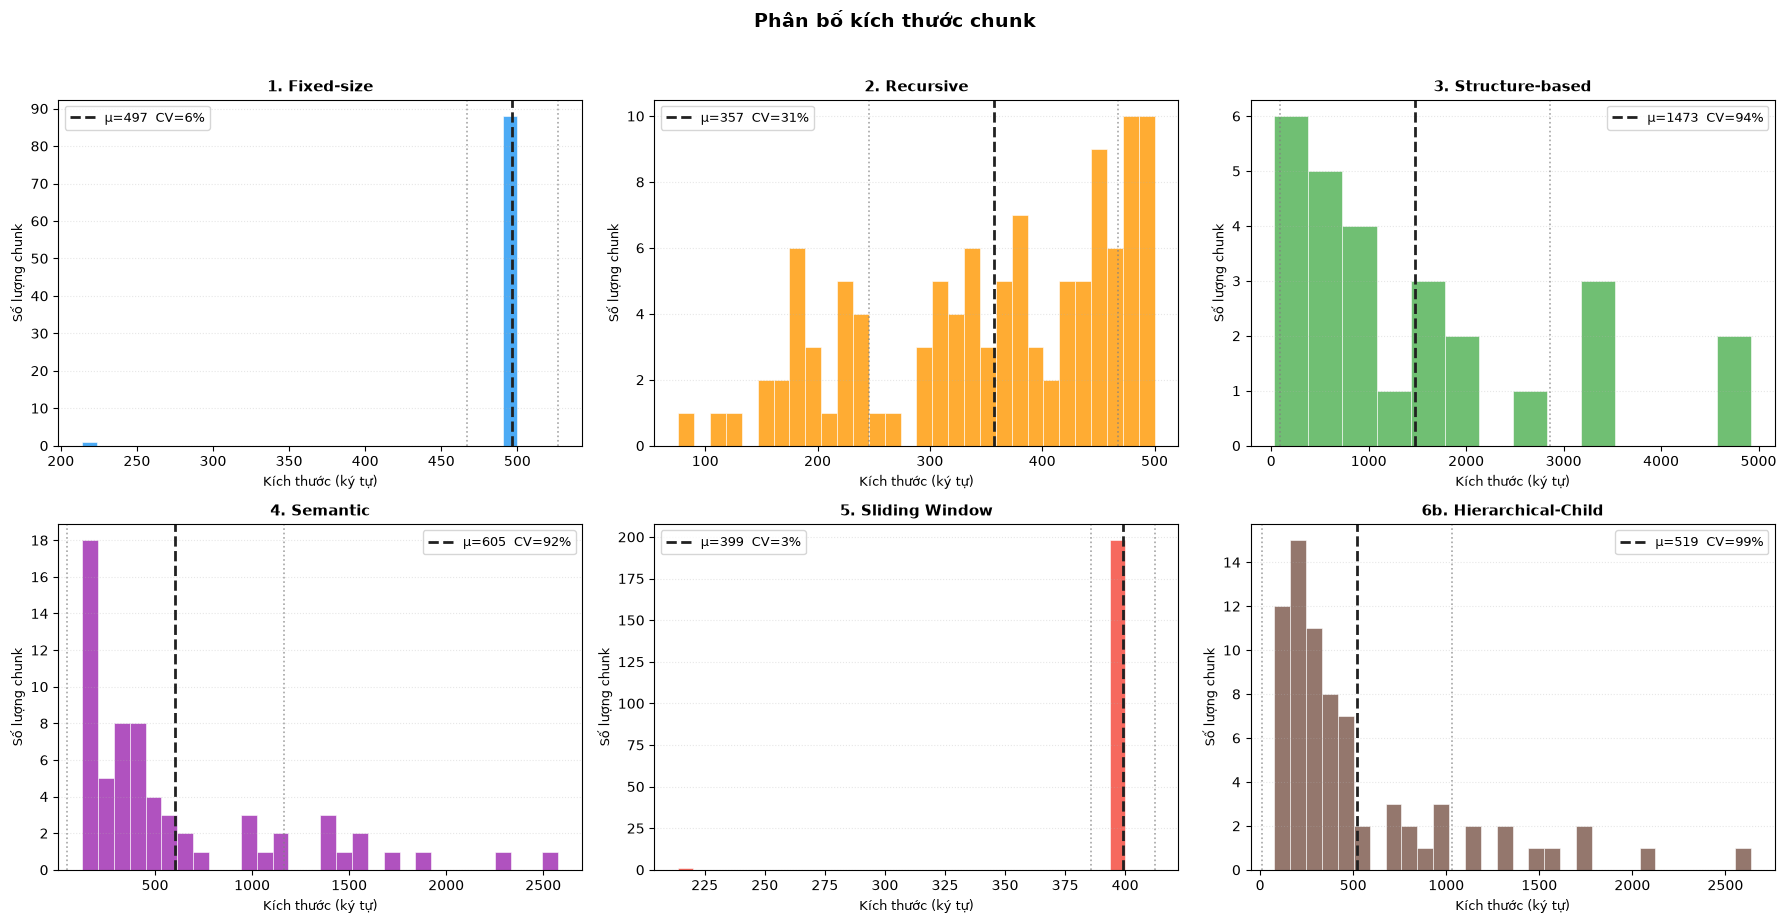

✅ Biểu đồ đã lưu: chunking_distribution.png


In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plot_data = [
    ("1. Fixed-size",          fixed_chunks,       "#2196F3"),
    ("2. Recursive",           recursive_chunks,    "#FF9800"),
    ("3. Structure-based",     struct_chunks,       "#4CAF50"),
    ("4. Semantic",            semantic_chunks,     "#9C27B0"),
    ("5. Sliding Window",      sliding_chunks,      "#F44336"),
    ("6b. Hierarchical-Child", clauses,          "#795548"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    "Phân bố kích thước chunk",
    fontsize=14, fontweight="bold", y=1.02
)

for ax, (title, chunks, color) in zip(axes.flat, plot_data):
    sizes = [len(c.text) for c in chunks]
    mean  = np.mean(sizes)
    std   = np.std(sizes)
    cv    = std / mean * 100

    ax.hist(sizes, bins=min(30, len(sizes)//2+1), color=color, alpha=0.80, edgecolor="white", linewidth=0.5)
    ax.axvline(mean, color="#212121", linestyle="--", linewidth=2.0,
               label=f"μ={mean:.0f}  CV={cv:.0f}%")
    ax.axvline(mean + std, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
    ax.axvline(mean - std, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    ax.set_xlabel("Kích thước (ký tự)", fontsize=9)
    ax.set_ylabel("Số lượng chunk", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle=":")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("chunking_distribution.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Biểu đồ đã lưu: chunking_distribution.png")